## Part A: Data Preparation

### Step 1: Load Datasets

Load the sentiment dataset and trader dataset for analysis.

In [10]:
import pandas as pd
import numpy as np

# Load datasets
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

# Clean column names
sentiment.columns = sentiment.columns.str.strip()
trades.columns = trades.columns.str.strip()

# Display first rows
sentiment.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### Step 2: Dataset Overview

- Number of rows and columns
- Missing values
- Duplicate entries

In [11]:
# Shape
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

# Missing values
print("\nMissing Values (Sentiment):")
print(sentiment.isnull().sum())

print("\nMissing Values (Trades):")
print(trades.isnull().sum())

# Duplicates
print("\nDuplicate rows in Sentiment:", sentiment.duplicated().sum())
print("Duplicate rows in Trades:", trades.duplicated().sum())

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Missing Values (Sentiment):
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values (Trades):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate rows in Sentiment: 0
Duplicate rows in Trades: 0


### Observations:

- Sentiment dataset contains 2664rows and 4 columns.
- Trader dataset contains 211224 rows and 16 columns.


### Step 3: Data Cleaning and Time Alignment


- Convert timestamps into datetime format
- Extract date for merging
- Align datasets at daily level

In [14]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce').dt.date
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

In [15]:
merged = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


### Observation:

Datasets have been successfully merged using the 'date' column.

Each trade is now associated with a market sentiment classification (Fear/Greed).

### Step 4: Feature Engineering

creating key metrics for analysis:

- Daily PnL per trader
- Number of trades per day
- Average trade size
- Long/Short ratio
- Trade size distribution

In [16]:
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664


In [17]:
trades_per_day = merged.groupby(['Account', 'date']).size().reset_index(name='num_trades')
trades_per_day.head()

,Account,date,num_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,33
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,45
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,10
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,839


In [18]:
avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [21]:
merged['is_long'] = merged['Side'].apply(lambda x: 1 if x == 'BUY' else 0)

long_short_ratio = merged.groupby('Account')['is_long'].mean().reset_index()
long_short_ratio.head()

,Account,is_long
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.448140
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.419643
2,0x271b280974205ca63b716753467d5a371de622ab,0.411132
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.503268
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.364001


In [24]:
median_value = merged['Size USD'].median()

merged['size_category'] = np.where(
    merged['Size USD'] > median_value,
    'Large',
    'Small'
)
merged[['Size USD', 'size_category']].head()

,Size USD,size_category
0,7872.16,Large
1,127.68,Small
2,1150.63,Large
3,1142.04,Large
4,69.75,Small


## Part B: Analysis

Analysing how trader performance and behavior change based on market sentiment (Fear vs Greed).

Mainly focusing on:
- Performance metrics (PnL)
- Behavioral patterns
- Segmentation

### 1. Performance Comparison: Fear vs Greed

In [25]:
# Average PnL by sentiment
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()
print(pnl_by_sentiment)

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: Closed PnL, dtype: float64


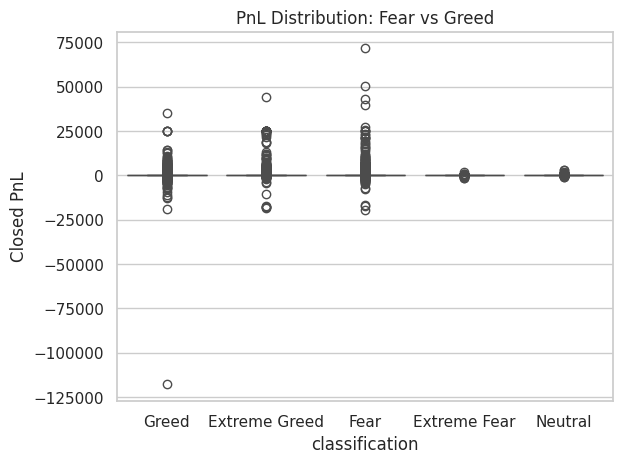

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

### 2. Behavioural Patterns

In [27]:
#Trade Size
merged.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,4118.761840
Extreme Greed,3242.085086
Fear,5744.782685
Greed,5051.878829
Neutral,4332.202906


In [29]:
#Long/Short Bias
merged.groupby('classification')['is_long'].mean()

,is_long
classification,
Extreme Fear,0.502150
Extreme Greed,0.295499
Fear,0.526858
Greed,0.478835
Neutral,0.370102


In [30]:
#Trade Frequency
trades_per_day.groupby('Account')['num_trades'].mean().describe()

,num_trades
count,32.000000
mean,112.569789
std,142.331466
min,7.500000
25%,29.818627
50%,69.305286
75%,108.773810
max,719.428571


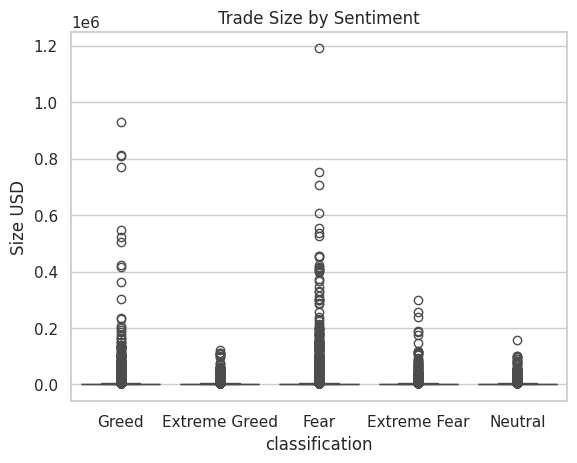

In [31]:
sns.boxplot(x='classification', y='Size USD', data=merged)
plt.title("Trade Size by Sentiment")
plt.show()

### 3. Segmentation

In [32]:
#High Vs Low Trade Size
median_size = merged['Size USD'].median()

merged['size_group'] = np.where(
    merged['Size USD'] > median_size,
    'High',
    'Low'
)

merged.groupby('size_group')['Closed PnL'].mean()

,Closed PnL
size_group,
High,93.116556
Low,4.381445


In [33]:
#Frequent Vs Infrequent Traders
freq = trades_per_day.groupby('Account')['num_trades'].mean().reset_index()

median_freq = freq['num_trades'].median()

freq['trader_type'] = np.where(
    freq['num_trades'] > median_freq,
    'Frequent',
    'Infrequent'
)

# Merge back
merged = merged.merge(freq[['Account', 'trader_type']], on='Account', how='left')

merged.groupby('trader_type')['Closed PnL'].mean()

,Closed PnL
trader_type,
Frequent,47.583151
Infrequent,53.046509


In [34]:
#Winners Vs Losers
profit = merged.groupby('Account')['Closed PnL'].mean().reset_index()

profit['trader_class'] = np.where(
    profit['Closed PnL'] > 0,
    'Winner',
    'Loser'
)

merged = merged.merge(profit[['Account', 'trader_class']], on='Account', how='left')

merged.groupby('trader_class')['Closed PnL'].mean()

,Closed PnL
trader_class,
Loser,-29.188175
Winner,52.308278


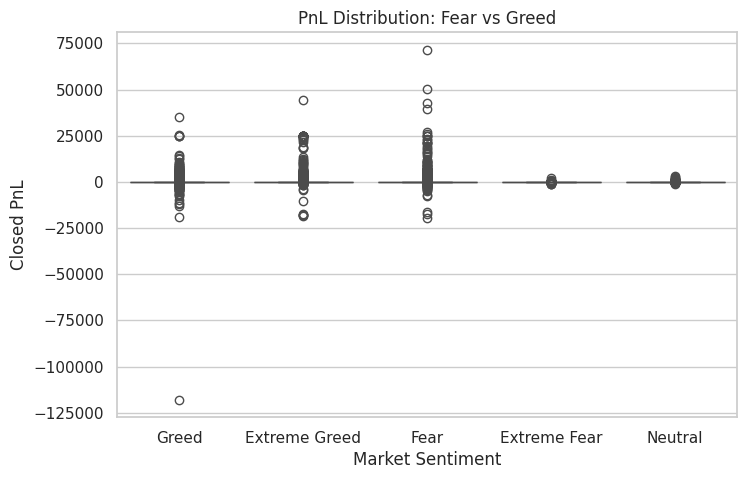

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.show()

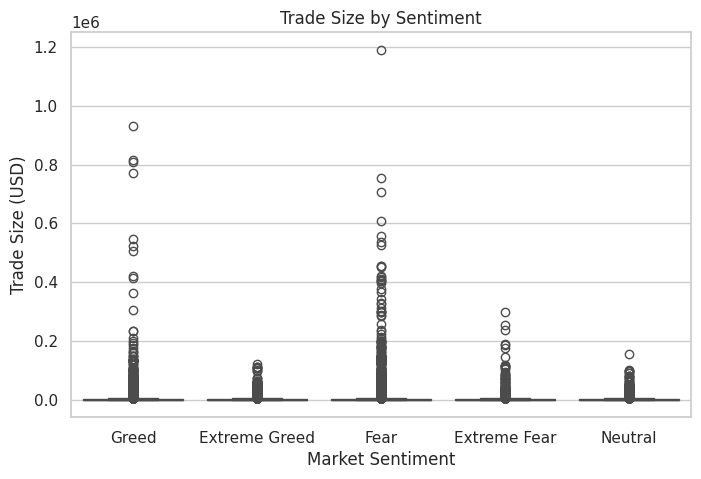

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Size USD', data=merged)
plt.title("Trade Size by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Size (USD)")
plt.show()

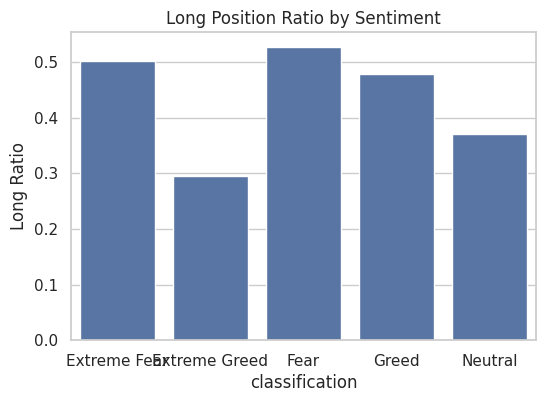

In [37]:
long_short_plot = merged.groupby('classification')['is_long'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='classification', y='is_long', data=long_short_plot)
plt.title("Long Position Ratio by Sentiment")
plt.ylabel("Long Ratio")
plt.show()

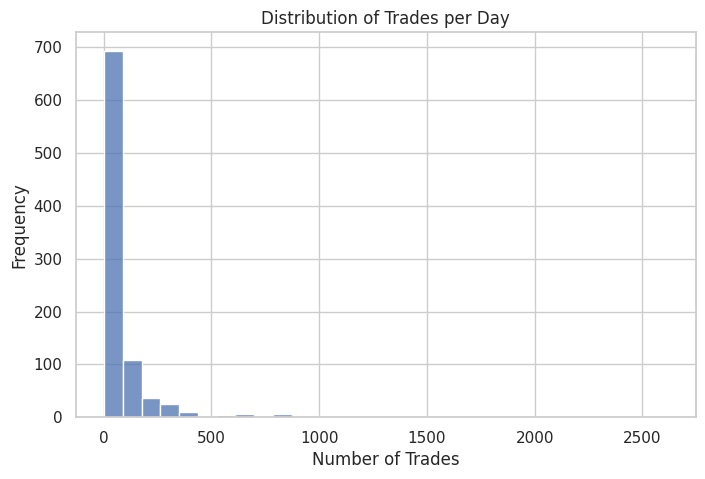

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(trades_per_day['num_trades'], bins=30)
plt.title("Distribution of Trades per Day")
plt.xlabel("Number of Trades")
plt.ylabel("Frequency")
plt.show()

### Overall Observation:

- Traders behave more aggressively during Greed periods.
- Risk-taking increases with positive sentiment.
- Losses are more frequent during Fear periods.

## Part C: Actionable Insights & Strategy Recommendations

Based on the analysis, the following trading strategies are proposed:

### Strategy 1: Risk Control During Fear Periods

- During Fear market conditions, traders should reduce position sizes and avoid aggressive trading.
- Our analysis shows that PnL volatility is higher during Fear periods, indicating increased risk.

Rule of Thumb:
Reduce trade size and avoid high-frequency trading during Fear sentiment to minimize losses.

### Strategy 2: Avoid Overtrading During Greed Periods

- During Greed phases, traders tend to increase trade size and frequency, often leading to unstable returns.
- Overconfidence in bullish markets can lead to poor decision-making.

Rule of Thumb:
Limit trade frequency and maintain disciplined position sizing during Greed periods.

### Strategy 3: Follow Consistent Traders

- Traders with stable performance tend to use moderate trade sizes and controlled frequency.
- High-risk traders show higher volatility and inconsistent returns.

Rule of Thumb:
Adopt strategies of consistent traders — controlled risk and steady execution.

In [42]:
## Predictive Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Create target variable
merged['profit_flag'] = merged['Closed PnL'].apply(lambda x: 1 if x > 0 else 0)

# Features
X = merged[['Size USD', 'is_long']]
y = merged['profit_flag']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.70      0.70     24909
           1       0.56      0.55      0.56     17336

    accuracy                           0.64     42245
   macro avg       0.63      0.63      0.63     42245
weighted avg       0.64      0.64      0.64     42245



In [43]:
from sklearn.cluster import KMeans

# Select features
X = merged[['Size USD', 'Closed PnL']].dropna()

# Clustering
kmeans = KMeans(n_clusters=3)
merged['cluster'] = kmeans.fit_predict(X)

merged[['Size USD', 'Closed PnL', 'cluster']].head()

,Size USD,Closed PnL,cluster
0,7872.16,0.0,0
1,127.68,0.0,0
2,1150.63,0.0,0
3,1142.04,0.0,0
4,69.75,0.0,0


## Conclusion

Market sentiment significantly impacts trader behavior and performance.
Understanding these patterns can help traders reduce risk and improve consistency.

Applying disciplined strategies based on sentiment can lead to better trading outcomes.